In [42]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

In [43]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [44]:
print(f"Banyak baris: {df.shape[0]}")
print(f"Banyak kolom: {df.shape[1]}")

Banyak baris: 1460
Banyak kolom: 81


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [46]:
miss = df.isnull().sum()
miss_perc = ((df.isnull().sum() / len(df)) * 100).round(2)
dtype = df.dtypes
miss_df = pd.DataFrame(
    {"Tipe Data": dtype, "Jumlah missing value": miss, "Persentase": miss_perc}
)

miss_df = miss_df[miss_df["Jumlah missing value"] > 0]
miss_df = miss_df.sort_values(by="Jumlah missing value" ,ascending=False)
miss_df

,Tipe Data,Jumlah missing value,Persentase
PoolQC,str,1453,99.52
MiscFeature,str,1406,96.30
Alley,str,1369,93.77
Fence,str,1179,80.75
MasVnrType,str,872,59.73
FireplaceQu,str,690,47.26
LotFrontage,float64,259,17.74
GarageType,str,81,5.55
GarageYrBlt,float64,81,5.55
GarageFinish,str,81,5.55


In [47]:
miss_del = []
for c in df.columns:
    if ((df[c].isnull().sum() / len(df)) * 100).round(2) >= 50:
        miss_del.append(c)
print(f"Fitur yang perlu dihapus: {miss_del}")

Fitur yang perlu dihapus: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


In [48]:
df = df.drop(columns = miss_del)
print("Fitur berhasil dihapus!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Banyak kolom: {df.shape[1]}")

Fitur berhasil dihapus!
Jumlah baris: 1460
Banyak kolom: 76


In [49]:
# NaN berarti rumah TIDAK MEMILIKI fasilitas tersebut (Fireplace, Garasi, atau Basement)
cat_none_cols = [
    'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
df[cat_none_cols] = df[cat_none_cols].fillna('None')

# Electrical hanya ada 1 missing value (murni hilang), isi dengan nilai terbanyak
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

# NaN berarti tidak ada luas lapisan batu bata (MasVnrArea) atau tidak ada garasi (GarageYrBlt)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)  # Atau diisi dengan df['YearBuilt']

# Menggunakan median per lingkungan agar jauh lebih akurat dibanding global mean/median
df['LotFrontage'] = df['LotFrontage'].fillna(
    df.groupby('Neighborhood')['LotFrontage'].transform('median')
)
# Backup jika masih ada NaN di LotFrontage
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

print(f"Sisa missing value: {df.isnull().sum().sum()}")


Sisa missing value: 0


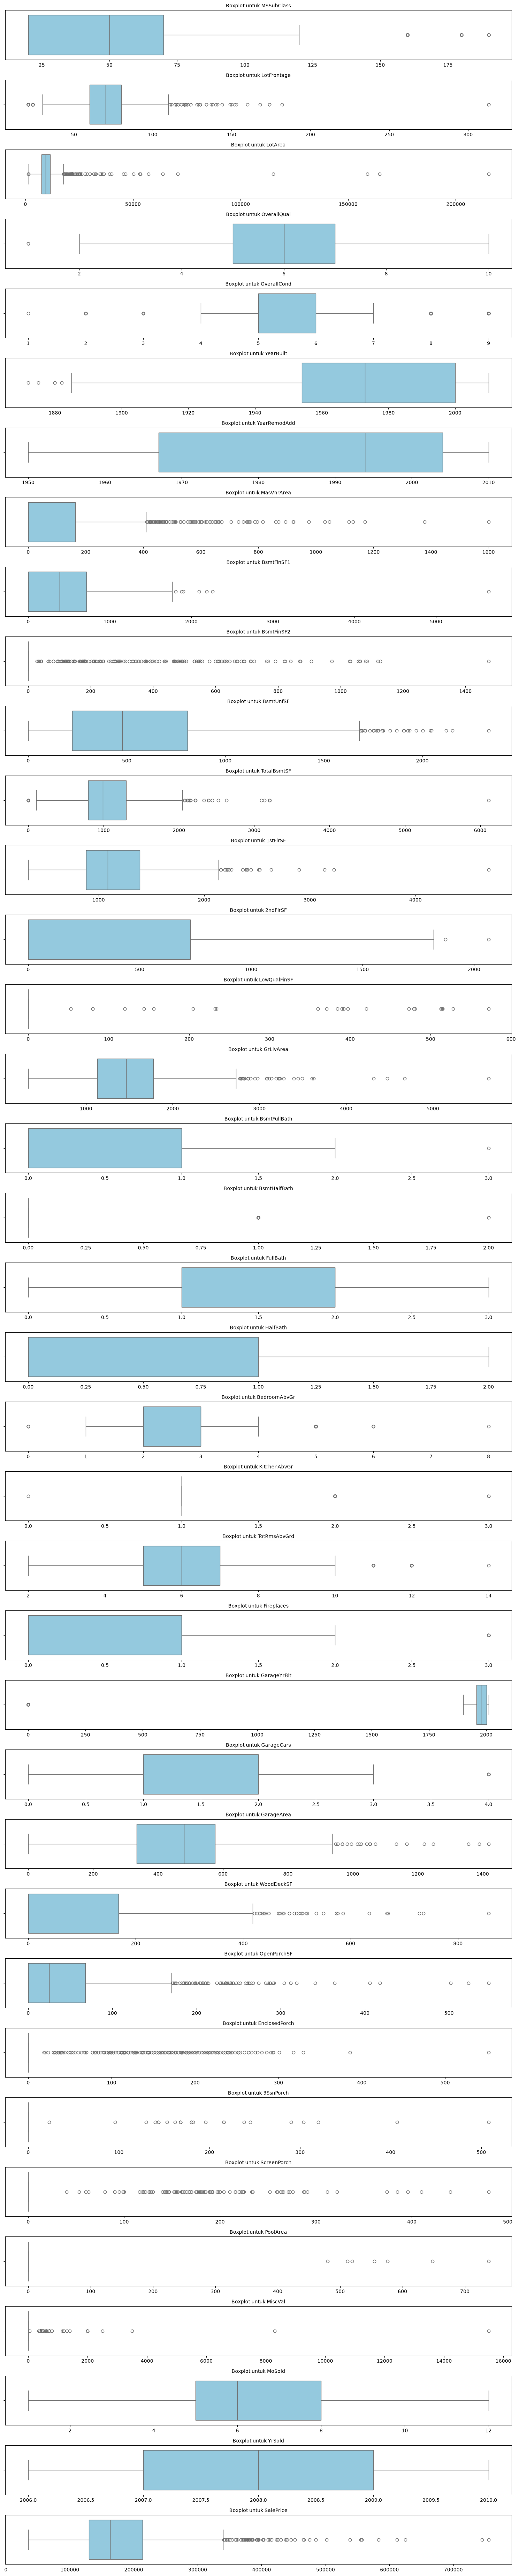

In [50]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

cols_to_plot = [c for c in num_cols if c not in ["Id"]]

plt.figure(figsize=(15, len(cols_to_plot) * 2))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(len(cols_to_plot), 1, i)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot untuk {col}", fontsize=10)
    plt.xlabel("")

plt.tight_layout()
plt.show()

In [51]:
# Hapus outlier ekstrem
outliers_ekstrem = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
df = df.drop(index=outliers_ekstrem).reset_index(drop=True)

print(f"Jumlah outlier ekstrem yang dihapus: {len(outliers_ekstrem)}")
print(f"Jumlah baris setelah penghapusan: {df.shape[0]}")


# Kolom numerik kontinu yang perlu disesuaikan nilainya (IQR capping)
num_cols_adjust = ['LotArea', 'LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea']

for col in num_cols_adjust:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Batasi (cap) nilai yang melebihi batas atas/bawah IQR
        df[col] = np.clip(df[col], lower_bound, upper_bound)

print("Penyesuaian outlier (IQR Capping) selesai!")

Jumlah outlier ekstrem yang dihapus: 2
Jumlah baris setelah penghapusan: 1458
Penyesuaian outlier (IQR Capping) selesai!


In [52]:
# Pisahkan kolom Id dan target SalePrice agar tidak terpengaruh transformasi
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_to_scale = [col for col in num_cols if col not in ['Id', 'SalePrice']]

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print(" Standarisasi variabel numerik selesai! (Mean = 0, Std = 1)")

# Ambil seluruh kolom kategorikal (tipe data object)
cat_cols = df.select_dtypes(include=['object', "str"]).columns.tolist()

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print(" One-Hot Encoding selesai!")
print(f"Bentuk dataset akhir (baris, kolom): {df_encoded.shape}")

df_encoded.head()

 Standarisasi variabel numerik selesai! (Mean = 0, Std = 1)
 One-Hot Encoding selesai!
Bentuk dataset akhir (baris, kolom): (1458, 244)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.073426,-0.246891,-0.331112,0.658506,-0.517649,1.052959,0.880362,0.803369,0.622222,...,0,0,0,0,1,0,0,0,1,0
1,2,-0.871868,0.587976,-0.010266,-0.068293,2.177825,0.158428,-0.428115,-0.666615,1.254080,...,0,0,0,0,1,0,0,0,1,0
2,3,0.073426,-0.079917,0.450078,0.658506,-0.517649,0.986698,0.831900,0.548372,0.111161,...,0,0,0,0,1,0,0,0,1,0
3,4,0.309749,-0.525179,-0.024216,0.658506,-0.517649,-1.862551,-0.718888,-0.666615,-0.516051,...,0,0,0,0,1,0,0,0,0,0
4,5,0.073426,0.810607,1.289857,1.385305,-0.517649,0.953567,0.734975,1.958356,0.503749,...,0,0,0,0,1,0,0,0,1,0


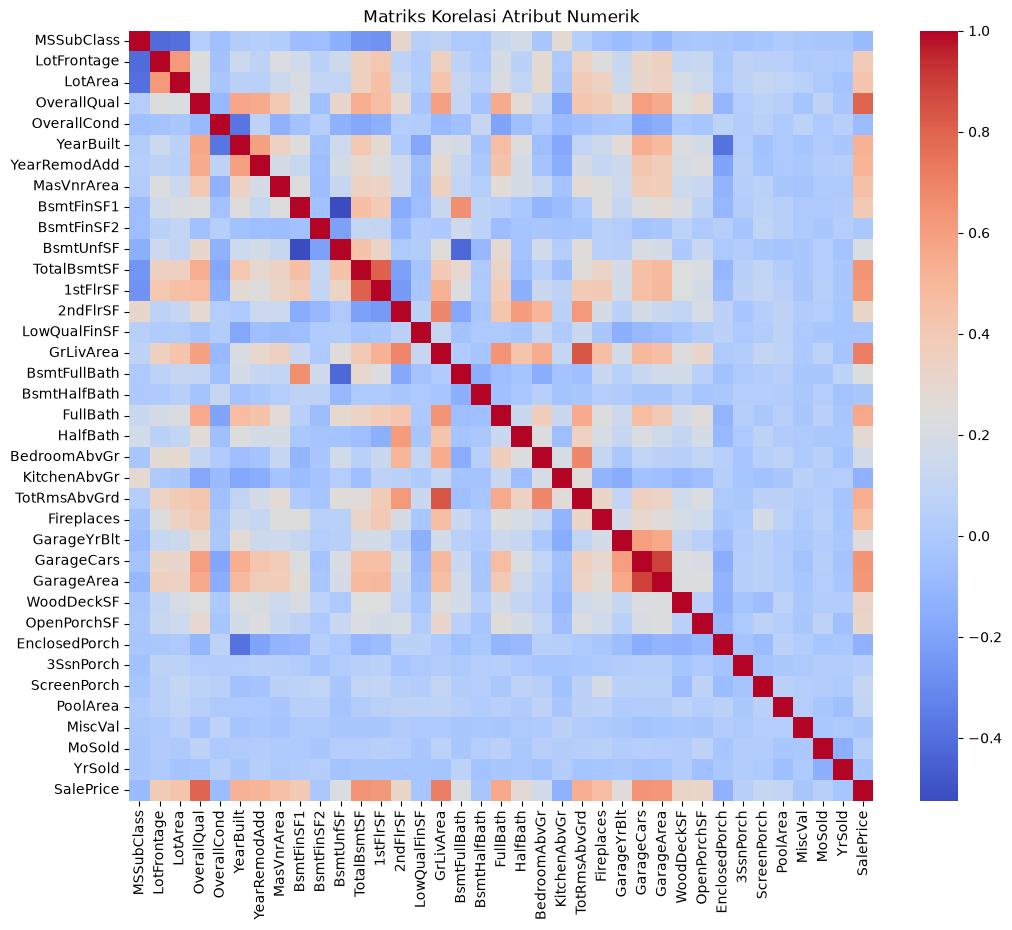

Pasangan fitur dengan korelasi tinggi (> 0.80):
 - TotalBsmtSF <--> 1stFlrSF (Korelasi: 0.8054)
 - GrLivArea <--> TotRmsAbvGrd (Korelasi: 0.8339)
 - GarageCars <--> GarageArea (Korelasi: 0.8873)

Fitur yang dibuang: ['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea']
Jumlah kolom tersisa setelah reduksi korelasi: 73
Bentuk df_encoded setelah reduksi korelasi: (1458, 241)


In [53]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Id']]

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matriks Korelasi Atribut Numerik")
plt.show()

upper_tri = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]

print("Pasangan fitur dengan korelasi tinggi (> 0.80):")
for col in upper_tri.columns:
    high_corr = upper_tri[col][upper_tri[col] > 0.80]
    for idx, val in high_corr.items():
        print(f" - {idx} <--> {col} (Korelasi: {val:.4f})")

df = df.drop(columns=to_drop)

print(f"\nFitur yang dibuang: {to_drop}")
print(f"Jumlah kolom tersisa setelah reduksi korelasi: {df.shape[1]}")

# Hapus juga fitur berkorelasi tinggi dari df_encoded
df_encoded = df_encoded.drop(columns=to_drop, errors='ignore')
print(f"Bentuk df_encoded setelah reduksi korelasi: {df_encoded.shape}")

Jumlah dimensi awal (fitur): 239
Jumlah dimensi setelah PCA: 131
Total varians yang berhasil dipertahankan: 90.03%


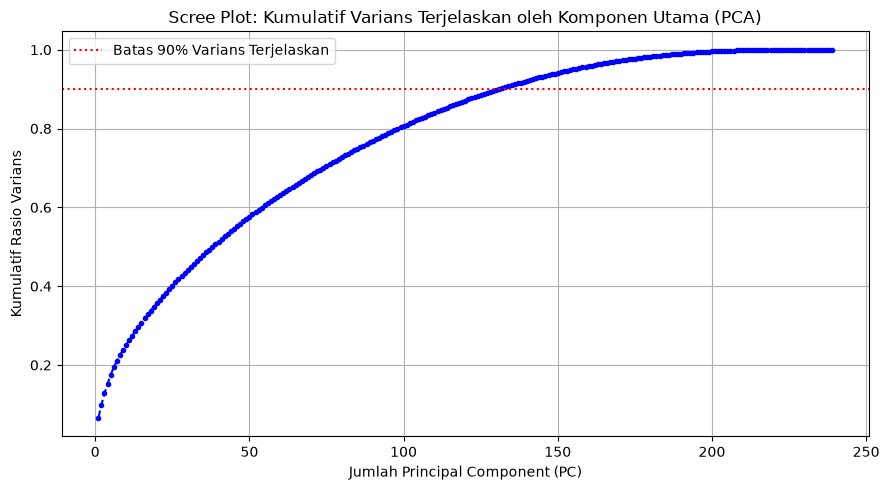

In [54]:
# Pisahkan ID dan Target (SalePrice) agar tidak masuk ke proses PCA
X = df_encoded.drop(columns=['Id', 'SalePrice'], errors='ignore')
y = df_encoded['SalePrice']

# Standarisasi seluruh fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Menentukan n_components=0.90 berarti PCA akan memilih jumlah komponen minimum
# yang mampu menjelaskan 90% total informasi/varians data
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

# Buat DataFrame hasil PCA
pca_cols = [f'PC{i+1}' for i in range(pca.n_components_)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

print(f"Jumlah dimensi awal (fitur): {X_scaled.shape[1]}")
print(f"Jumlah dimensi setelah PCA: {pca.n_components_}")
print(f"Total varians yang berhasil dipertahankan: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Evaluasi varians akumulatif dari seluruh komponen
pca_full = PCA().fit(X_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='.', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle=':', label='Batas 90% Varians Terjelaskan')
plt.title('Scree Plot: Kumulatif Varians Terjelaskan oleh Komponen Utama (PCA)')
plt.xlabel('Jumlah Principal Component (PC)')
plt.ylabel('Kumulatif Rasio Varians')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
df_final_pca = df_pca.copy()
df_final_pca['SalePrice'] = y.values

filename = "Dataset_final.csv"
df_final_pca.to_csv(filename, index=False)

print(f"Dataset PCA berhasil disimpan ke {filename}")
print(f"Bentuk dataset akhir: {df_final_pca.shape}")

Dataset PCA berhasil disimpan ke Dataset_final.csv
Bentuk dataset akhir: (1458, 132)
